# Simulate Exhausted T cells (immune-resistance)

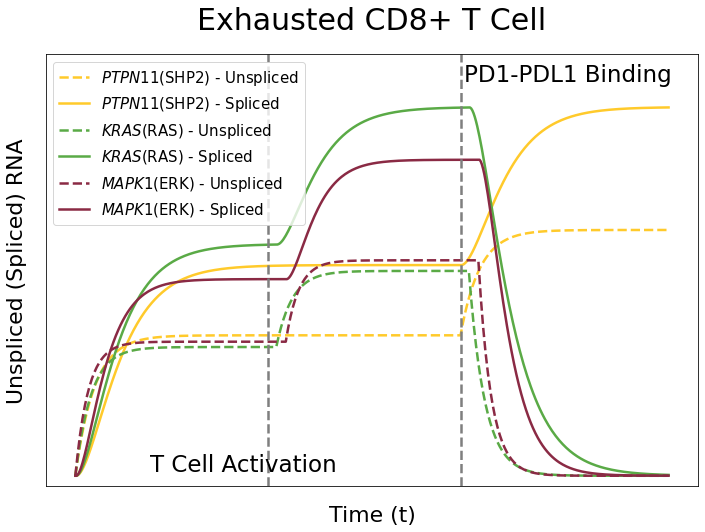

In [1]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 200, 500)
dt = t[1] - t[0]

activation_time = 65.0
bind_time = 130.0

# Baseline of genes: PTPN11 (SHP2), KRAS (RAS), MAPK1 (ERK)
alpha_pre = {
    "PTPN11(SHP2)": 0.2,
    "KRAS(RAS)": 0.22,
    "MAPK1(ERK)": 0.28,
}
beta_pre = {
    "PTPN11(SHP2)": 0.15,
    "KRAS(RAS)": 0.18,
    "MAPK1(ERK)": 0.22,
}
gamma_pre = {
    "PTPN11(SHP2)": 0.1,
    "KRAS(RAS)": 0.1,
    "MAPK1(ERK)": 0.15,
}

# After activation (at t=65), transcription rates increase
alpha_mid = {
    "PTPN11(SHP2)": 0.2,
    "KRAS(RAS)": 0.35,
    "MAPK1(ERK)": 0.45,
}
beta_mid = {
    "PTPN11(SHP2)": 0.15,
    "KRAS(RAS)": 0.18,
    "MAPK1(ERK)": 0.22,
}
gamma_mid = {
    "PTPN11(SHP2)": 0.1,
    "KRAS(RAS)": 0.1,
    "MAPK1(ERK)": 0.15,
}

# After PD1-PDL1 binding (at t=130), SHP2 increases while others decrease
alpha_post = {
    "PTPN11(SHP2)": 0.35,
    "KRAS(RAS)": 0,
    "MAPK1(ERK)": 0,
}
beta_post = {
    "PTPN11(SHP2)": 0.15,
    "KRAS(RAS)": 0.18,
    "MAPK1(ERK)": 0.22,
}
gamma_post = {
    "PTPN11(SHP2)": 0.1,
    "KRAS(RAS)": 0.1,
    "MAPK1(ERK)": 0.15,
}


def simulate_rna_velocity(alpha_pre, beta_pre, gamma_pre, alpha_mid, beta_mid, gamma_mid, alpha_post, beta_post, gamma_post, t, bind_time, delay_time=0):
    u = np.zeros_like(t)
    s = np.zeros_like(t)
    velocity = np.zeros_like(t)
    
    for i in range(1, len(t)):
        if t[i] < activation_time:
            # Before activation
            du = (alpha_pre - beta_pre * u[i - 1]) * dt
            ds = (beta_pre * u[i - 1] - gamma_pre * s[i - 1]) * dt
        elif t[i] >= bind_time:
            # After PD1-PDL1 binding
            if t[i] >= bind_time + delay_time:
                # After PD1-PDL1 binding, with potential delay
                du = (alpha_post - beta_post * u[i - 1]) * dt
                ds = (beta_post * u[i - 1] - gamma_post * s[i - 1]) * dt
            else:
                # During delay, keep pre-binding rates
                du = (alpha_mid - beta_mid * u[i - 1]) * dt
                ds = (beta_mid * u[i - 1] - gamma_mid * s[i - 1]) * dt
        else:
            # During activation but not binding
            if t[i] >= activation_time + delay_time:
                # After activation, with potential delay
                du = (alpha_mid - beta_mid * u[i - 1]) * dt
                ds = (beta_mid * u[i - 1] - gamma_mid * s[i - 1]) * dt
            else:
                # During delay, keep pre-activation rates
                du = (alpha_pre - beta_pre * u[i - 1]) * dt
                ds = (beta_pre * u[i - 1] - gamma_pre * s[i - 1]) * dt
            

        u[i] = u[i - 1] + du
        s[i] = s[i - 1] + ds
        velocity[i] = ds / dt
    
    return u, s

genes = ["PTPN11(SHP2)", "KRAS(RAS)", "MAPK1(ERK)"]
results = {}

for gene in genes:
    
    if gene in ["KRAS(RAS)", "ZAP70"] :
        delay_time = 3
    elif gene in ["MAPK1(ERK)"] :
        delay_time = 6
    else:
        delay_time = 0
        
    results[gene] = simulate_rna_velocity(
        alpha_pre[gene], beta_pre[gene], gamma_pre[gene],
        alpha_mid[gene], beta_mid[gene], gamma_mid[gene],
        alpha_post[gene], beta_post[gene], gamma_post[gene],
        t, bind_time, delay_time
    )
    
color_dict = {"PTPN11(SHP2)":"#FFCA2B", "KRAS(RAS)":"#5AAA46", "MAPK1(ERK)":"#8A2A44"}

plt.figure(figsize=(10, 7.5))
for gene in genes:
    input_text1 = f"{gene} - Unspliced"
    input_text2 = f"{gene} - Spliced"
    gene_name = input_text1.split('(')[0]
    rest_of_text1 = input_text1[len(gene_name):]
    rest_of_text2 = input_text2[len(gene_name):]

    formatted_label1 = f"${{\\it {gene_name}}}$" + rest_of_text1
    formatted_label2 = f"${{\\it {gene_name}}}$" + rest_of_text2

    plt.plot(t, results[gene][0], color=color_dict[gene], linestyle='--', label=formatted_label1, linewidth=2.5)
    plt.plot(t, results[gene][1], color=color_dict[gene], linestyle='-', label=formatted_label2, linewidth=2.5)
plt.axvline(x=activation_time, color='tab:gray', linestyle='--', linewidth=2.5)
plt.text(activation_time - 40, 0, 'T Cell Activation', rotation=0, verticalalignment='bottom', fontsize=23)
plt.axvline(x=bind_time, color='tab:gray', linestyle='--', linewidth=2.5)
plt.text(bind_time + 1, 3.7, 'PD1-PDL1 Binding', rotation=0, verticalalignment='bottom', fontsize=23)
plt.title('Exhausted CD8+ T Cell', fontsize=30, pad=25)
plt.xlabel('Time (t)', fontsize=22, labelpad=15)
plt.ylabel('Unspliced (Spliced) RNA',  fontsize=22, labelpad=15)
plt.legend(fontsize=15)
plt.xticks([])
plt.yticks([])
plt.ylim(-0.1, 4.0)

plt.savefig("../Data/Exhausted_CD8+_T_Cell_dynamicalcurve.tif", format='tiff', dpi=72, bbox_inches='tight')
plt.tight_layout()
plt.show()


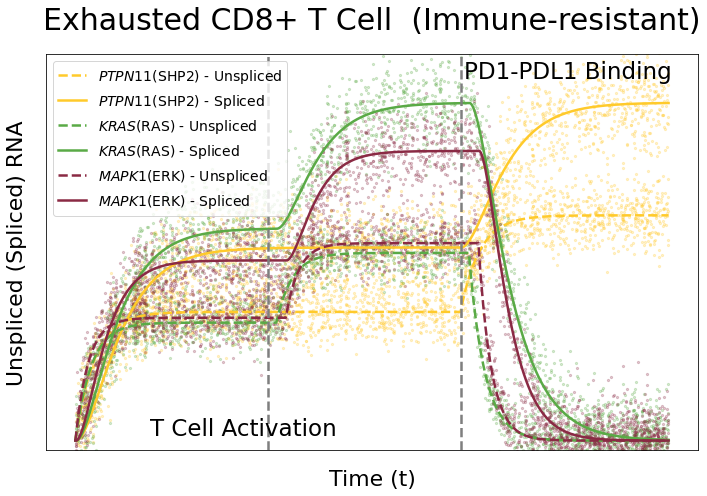

,time,unspliced,spliced,gene
0,109.762701,1.313737,2.083915,PTPN11(SHP2)
1,143.037873,2.458349,3.308495,PTPN11(SHP2)
2,120.552675,1.024338,2.395247,PTPN11(SHP2)
3,108.976637,1.362013,2.421451,PTPN11(SHP2)
4,84.730960,1.037565,2.227601,PTPN11(SHP2)
...,...,...,...,...
5995,158.256310,0.376996,0.111694,MAPK1(ERK)
5996,144.239623,0.133695,1.830564,MAPK1(ERK)
5997,96.021561,2.468337,3.401445,MAPK1(ERK)
5998,128.772807,2.164290,3.237218,MAPK1(ERK)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(0)

n_cells = 2000
noise_std_frac = 0.08

np.random.seed(0)
sampled_times = np.random.uniform(t[0], t[-1], size=n_cells)

dot_data = []

plt.figure(figsize=(10, 7))

for gene in genes:

    u_curve, s_curve = results[gene]

    u_interp = np.interp(sampled_times, t, u_curve)
    s_interp = np.interp(sampled_times, t, s_curve)

    u_obs = np.random.normal(u_interp, noise_std_frac * np.max(u_curve))
    s_obs = np.random.normal(s_interp, noise_std_frac * np.max(s_curve))

    dot_data.extend([
        {"time": time, "unspliced": u, "spliced": s, "gene": gene}
        for time, u, s in zip(sampled_times, u_obs, s_obs)
    ])
    
    input_text1 = f"{gene} - Unspliced"
    input_text2 = f"{gene} - Spliced"
    gene_name = input_text1.split('(')[0]
    rest_of_text1 = input_text1[len(gene_name):]
    rest_of_text2 = input_text2[len(gene_name):]

    formatted_label1 = f"${{\\it {gene_name}}}$" + rest_of_text1
    formatted_label2 = f"${{\\it {gene_name}}}$" + rest_of_text2

    plt.plot(t, u_curve, color=color_dict[gene], linestyle='--', linewidth=2.5, label=formatted_label1)
    plt.plot(t, s_curve, color=color_dict[gene], linestyle='-', linewidth=2.5, label=formatted_label2)

    plt.scatter(sampled_times, u_obs, s=5, color=color_dict[gene], alpha=0.25)
    plt.scatter(sampled_times, s_obs, s=5, color=color_dict[gene], alpha=0.25)

plt.axvline(x=activation_time, color='tab:gray', linestyle='--', linewidth=2.5)
plt.text(activation_time - 40, 0, 'T Cell Activation', rotation=0, verticalalignment='bottom', fontsize=23)
plt.axvline(x=bind_time, color='tab:gray', linestyle='--', linewidth=2.5)
plt.text(bind_time + 1, 3.7, 'PD1-PDL1 Binding', rotation=0, verticalalignment='bottom', fontsize=23)

plt.title('Exhausted CD8+ T Cell  (Immune-resistant)', fontsize=30, pad=25)
plt.xlabel('Time (t)', fontsize=22, labelpad=15)
plt.ylabel('Unspliced (Spliced) RNA', fontsize=22, labelpad=15)
plt.legend(fontsize=14)
plt.xticks([])
plt.yticks([])
plt.ylim(-0.1, 4.0)
plt.tight_layout()
plt.savefig("../Data/Exhausted_CD8+_T_Cell.tif", format='tiff', dpi=72, bbox_inches='tight')
plt.show()

dot_T_exh = pd.DataFrame(dot_data)

dot_T_exh

# Simulated activated T cells (immune sensitive)

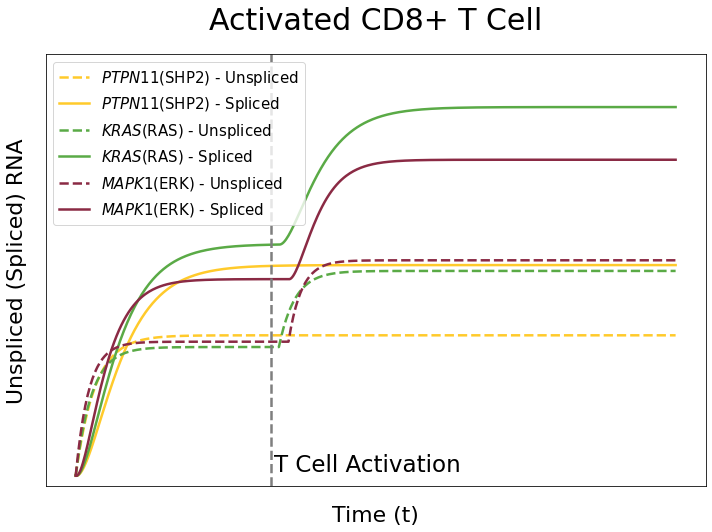

In [3]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 200, 500)
dt = t[1] - t[0]

activation_time = 65

# Baseline of genes: PTPN11 (SHP2), KRAS (RAS), MAPK1 (ERK)
alpha_pre_activation = {
    "PTPN11(SHP2)": 0.2,
    "KRAS(RAS)": 0.22,
    "MAPK1(ERK)": 0.28,
}
beta_pre_activation = {
    "PTPN11(SHP2)": 0.15,
    "KRAS(RAS)": 0.18,
    "MAPK1(ERK)": 0.22,
}
gamma_pre_activation = {
    "PTPN11(SHP2)": 0.1,
    "KRAS(RAS)": 0.1,
    "MAPK1(ERK)": 0.15,
}

# After activation (at t=65), transcription rates increase
alpha_post_activation = {
    "PTPN11(SHP2)": 0.2,
    "KRAS(RAS)": 0.35,
    "MAPK1(ERK)": 0.45,
}
beta_post_activation = {
    "PTPN11(SHP2)": 0.15,
    "KRAS(RAS)": 0.18,
    "MAPK1(ERK)": 0.22,
}
gamma_post_activation = {
    "PTPN11(SHP2)": 0.1,
    "KRAS(RAS)": 0.1,
    "MAPK1(ERK)": 0.15,
}


def simulate_rna_velocity(alpha_pre, beta_pre, gamma_pre, alpha_post, beta_post, gamma_post, t, activation_time, delay_time):
    u = np.zeros_like(t)
    s = np.zeros_like(t)
    velocity = np.zeros_like(t)
    
    for i in range(1, len(t)):
        if t[i] < activation_time:
            # Before activation
            du = (alpha_pre - beta_pre * u[i - 1]) * dt
            ds = (beta_pre * u[i - 1] - gamma_pre * s[i - 1]) * dt
        if t[i] >= activation_time + delay_time:
            # After activation, with potential delay
            du = (alpha_post - beta_post * u[i - 1]) * dt
            ds = (beta_post * u[i - 1] - gamma_post * s[i - 1]) * dt
        else:
            # During delay, keep pre-binding rates
            du = (alpha_pre - beta_pre * u[i - 1]) * dt
            ds = (beta_pre * u[i - 1] - gamma_pre * s[i - 1]) * dt

        u[i] = u[i - 1] + du
        s[i] = s[i - 1] + ds
        velocity[i] = du / dt
    
    return u, s

genes = ["PTPN11(SHP2)", "KRAS(RAS)", "MAPK1(ERK)"]
results = {}

for gene in genes:
    
    if gene in ["KRAS(RAS)", "ZAP70"] :
        delay_time = 3
    elif gene in ["MAPK1(ERK)"] :
        delay_time = 6
    else:
        delay_time = 0
        
    results[gene] = simulate_rna_velocity(
        alpha_pre_activation[gene], beta_pre_activation[gene], gamma_pre_activation[gene],
        alpha_post_activation[gene], beta_post_activation[gene], gamma_post_activation[gene],
        t, activation_time, delay_time
    )
    
color_dict = {"PTPN11(SHP2)":"#FFCA2B", "KRAS(RAS)":"#5AAA46", "MAPK1(ERK)":"#8A2A44"}

plt.figure(figsize=(10, 7.5))
for gene in genes:
    input_text1 = f"{gene} - Unspliced"
    input_text2 = f"{gene} - Spliced"
    gene_name = input_text1.split('(')[0]
    rest_of_text1 = input_text1[len(gene_name):]
    rest_of_text2 = input_text2[len(gene_name):]

    formatted_label1 = f"${{\\it {gene_name}}}$" + rest_of_text1
    formatted_label2 = f"${{\\it {gene_name}}}$" + rest_of_text2

    plt.plot(t, results[gene][0], color=color_dict[gene], linestyle='--', label=formatted_label1, linewidth=2.5)
    plt.plot(t, results[gene][1], color=color_dict[gene], linestyle='-', label=formatted_label2, linewidth=2.5)
plt.axvline(x=activation_time, color='tab:gray', linestyle='--', linewidth=2.5)
plt.text(activation_time + 1, 0, 'T Cell Activation', rotation=0, verticalalignment='bottom', fontsize=23)
plt.title('Activated CD8+ T Cell', fontsize=30, pad=25)
plt.xlabel('Time (t)', fontsize=22, labelpad=15)
plt.ylabel('Unspliced (Spliced) RNA',  fontsize=22, labelpad=15)
plt.legend(fontsize=15)
plt.xticks([])
plt.yticks([])
plt.ylim(-0.1, 4.0)

plt.savefig("../Data/Activated_CD8+_T_Cell_dynamicalcurve.tif", format='tiff', dpi=72, bbox_inches='tight')
plt.tight_layout()
plt.show()


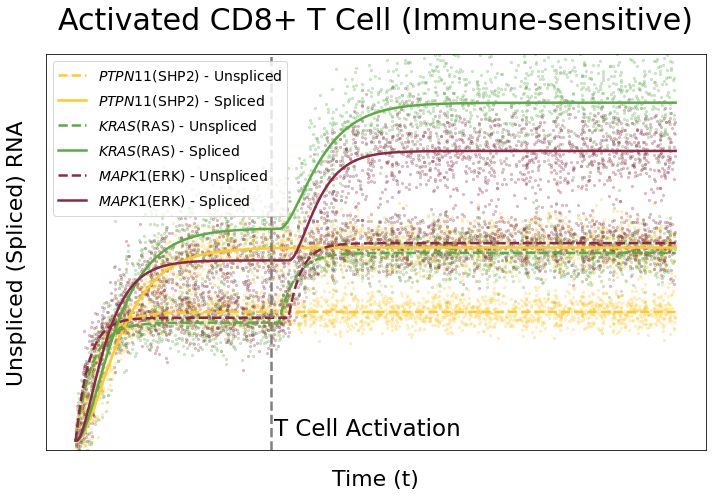

,time,unspliced,spliced,gene
0,83.404401,1.441125,1.827177,PTPN11(SHP2)
1,144.064899,1.355438,2.098151,PTPN11(SHP2)
2,0.022875,-0.148388,0.007076,PTPN11(SHP2)
3,60.466515,1.400088,1.813260,PTPN11(SHP2)
4,29.351178,1.351087,1.768242,PTPN11(SHP2)
...,...,...,...,...
5995,89.501628,1.874759,2.989228,MAPK1(ERK)
5996,36.825511,1.367320,1.961170,MAPK1(ERK)
5997,165.746570,2.140048,3.446036,MAPK1(ERK)
5998,6.199592,0.926301,0.251005,MAPK1(ERK)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(0)

n_cells = 2000
noise_std_frac = 0.08

np.random.seed(1)
sampled_times = np.random.uniform(t[0], t[-1], size=n_cells)

dot_data = []

plt.figure(figsize=(10, 7))

for gene in genes:
    u_curve, s_curve = results[gene]
    
    u_interp = np.interp(sampled_times, t, u_curve)
    s_interp = np.interp(sampled_times, t, s_curve)

    u_obs = np.random.normal(u_interp, noise_std_frac * np.max(u_curve))
    s_obs = np.random.normal(s_interp, noise_std_frac * np.max(s_curve))
    
    dot_data.extend([
        {"time": time, "unspliced": u, "spliced": s, "gene": gene}
        for time, u, s in zip(sampled_times, u_obs, s_obs)
    ])
    
    input_text1 = f"{gene} - Unspliced"
    input_text2 = f"{gene} - Spliced"
    gene_name = input_text1.split('(')[0]
    rest_of_text1 = input_text1[len(gene_name):]
    rest_of_text2 = input_text2[len(gene_name):]

    formatted_label1 = f"${{\\it {gene_name}}}$" + rest_of_text1
    formatted_label2 = f"${{\\it {gene_name}}}$" + rest_of_text2
    
    plt.plot(t, u_curve, color=color_dict[gene], linestyle='--', linewidth=2.5, label=formatted_label1)
    plt.plot(t, s_curve, color=color_dict[gene], linestyle='-', linewidth=2.5, label=formatted_label2)

    plt.scatter(sampled_times, u_obs, s=5, color=color_dict[gene], alpha=0.25)
    plt.scatter(sampled_times, s_obs, s=5, color=color_dict[gene], alpha=0.25)

plt.axvline(x=activation_time, color='tab:gray', linestyle='--', linewidth=2.5)
plt.text(activation_time + 1, 0, 'T Cell Activation', rotation=0, verticalalignment='bottom', fontsize=23)

plt.title('Activated CD8+ T Cell (Immune-sensitive)', fontsize=30, pad=25)
plt.xlabel('Time (t)', fontsize=22, labelpad=15)
plt.ylabel('Unspliced (Spliced) RNA', fontsize=22, labelpad=15)
plt.legend(fontsize=14)
plt.xticks([])
plt.yticks([])
plt.ylim(-0.1, 4.0)
plt.tight_layout()
plt.savefig("../Data/Activated_CD8+_T_Cell.tif", format='tiff', dpi=72, bbox_inches='tight')
plt.show()

dot_T_act = pd.DataFrame(dot_data)

dot_T_act

# Save data

In [5]:
from tqdm.notebook import tqdm
import anndata

dot_T_cmb = dot_T_exh.append(dot_T_act)
dot_T_cmb['X'] = dot_T_cmb['unspliced'] + dot_T_cmb['spliced']
dot_T_cmb['T_area'] = ['exhausted']*dot_T_exh.shape[0] + ['activated']*dot_T_act.shape[0]


dot_T_cmb_convert = pd.DataFrame(index = dot_T_cmb['time'].unique(), columns=['T_area', 'PTPN11(SHP2)_unspliced', 'KRAS(RAS)_unspliced', 'MAPK1(ERK)_unspliced', 'PTPN11(SHP2)_spliced', 'KRAS(RAS)_spliced', 'MAPK1(ERK)_spliced'])

for i in tqdm(dot_T_cmb_convert.index):
    data = dot_T_cmb[dot_T_cmb['time'] == i]
    dot_T_cmb_convert.loc[i, 'T_area'] = data['T_area'].values[0]
    dot_T_cmb_convert.loc[i, 'PTPN11(SHP2)_unspliced'] = data[data['gene'] == 'PTPN11(SHP2)']['unspliced'].values[0]
    dot_T_cmb_convert.loc[i, 'PTPN11(SHP2)_spliced'] = data[data['gene'] == 'PTPN11(SHP2)']['spliced'].values[0]
    dot_T_cmb_convert.loc[i, 'KRAS(RAS)_unspliced'] = data[data['gene'] == 'KRAS(RAS)']['unspliced'].values[0]
    dot_T_cmb_convert.loc[i, 'KRAS(RAS)_spliced'] = data[data['gene'] == 'KRAS(RAS)']['spliced'].values[0]
    dot_T_cmb_convert.loc[i, 'MAPK1(ERK)_unspliced'] = data[data['gene'] == 'MAPK1(ERK)']['unspliced'].values[0]
    dot_T_cmb_convert.loc[i, 'MAPK1(ERK)_spliced'] = data[data['gene'] == 'MAPK1(ERK)']['spliced'].values[0]
dot_T_cmb_convert['time'] = dot_T_cmb_convert.index
dot_T_cmb_convert.index = range(dot_T_cmb_convert.shape[0])

adata = anndata.AnnData(dot_T_cmb_convert[['PTPN11(SHP2)_unspliced', 'KRAS(RAS)_unspliced', 'MAPK1(ERK)_unspliced']].values + dot_T_cmb_convert[['PTPN11(SHP2)_spliced', 'KRAS(RAS)_spliced', 'MAPK1(ERK)_spliced']].values,
                        obs=dot_T_cmb_convert[['T_area', 'time']],
                        var=pd.DataFrame(index=['PTPN11', 'KRAS', 'MAPK1']),
                        layers={'unspliced': dot_T_cmb_convert[['PTPN11(SHP2)_unspliced', 'KRAS(RAS)_unspliced', 'MAPK1(ERK)_unspliced']].values,
                                'spliced': dot_T_cmb_convert[['PTPN11(SHP2)_spliced', 'KRAS(RAS)_spliced', 'MAPK1(ERK)_spliced']].values})
adata.layers['unspliced'] = adata.layers['unspliced'].astype(np.float32)
adata.layers['spliced'] = adata.layers['spliced'].astype(np.float32)
adata.write_h5ad("../Data/simulated_T_cell.h5ad")

adata

  0%|          | 0/4000 [00:00<?, ?it/s]

/home/ylz0045/software/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:27: FutureWarning: X.dtype being converted to np.float32 from object. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
/home/ylz0045/software/anaconda3/lib/python3.7/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 4000 × 3
    obs: 'T_area', 'time'
    layers: 'unspliced', 'spliced'

# Plot

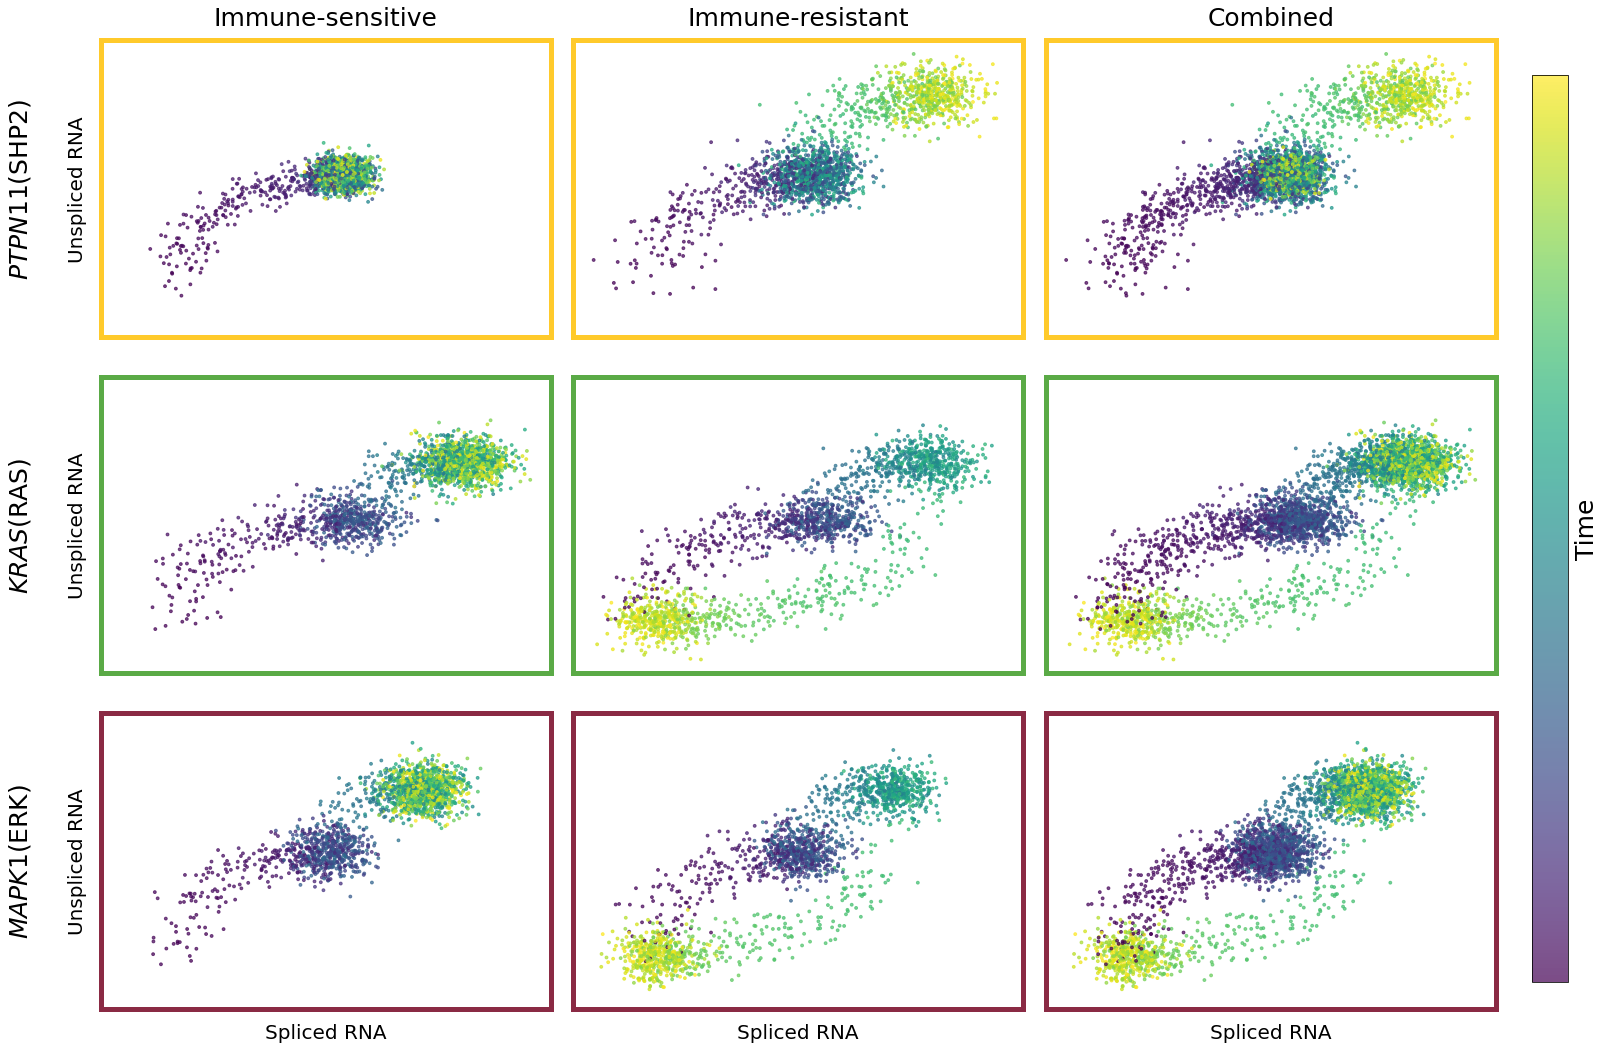

In [6]:
import matplotlib.pyplot as plt

genes = ['PTPN11(SHP2)', 'KRAS(RAS)', 'MAPK1(ERK)']
conditions = ['Immune-sensitive', 'Immune-resistant', 'Combined']
datasets = [dot_T_act, dot_T_exh, dot_T_cmb]

border_colors = ['#FFCA2B', '#5AAA46', '#8A2A44']

fig, axes = plt.subplots(3, 3, figsize=(25, 18), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.05, hspace=0.1)

for row_idx, gene in enumerate(genes):
    for col_idx, (condition, df) in enumerate(zip(conditions, datasets)):
        ax = axes[row_idx, col_idx]
        data = df[df['gene'] == gene]

        sc = ax.scatter(data['spliced'], data['unspliced'], s=8, c=data['time'], cmap='viridis', alpha=0.7)
        
        ax.set_aspect('equal', adjustable='box')
        
        border_color = border_colors[row_idx]
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(5)
        
        if col_idx == 0:
            ax.set_ylabel('Unspliced RNA', fontsize=20, labelpad=10)
        else:
            ax.set_yticks([])

        if row_idx == 2:
            ax.set_xlabel('Spliced RNA', fontsize=20, labelpad=10)
        else:
            ax.set_xticks([])
        
        if row_idx == 0:
            ax.set_title(condition, fontsize=25, pad=15)

        if col_idx == 0:
            ax.annotate(f"${{\\it {gene.split('(')[0]}}}$" + '(' + gene.split('(')[1], xy=(-0.15, 0.5), xycoords='axes fraction', fontsize=25, ha='right', va='center', rotation=90)

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('Time', fontsize=25)
cbar.set_ticks([])

plt.savefig("../Data/RNA_velocity_simulation_scatter.tif", format='tiff', dpi=72, bbox_inches='tight')
plt.show()

# Compute velocity

In [7]:
activation_time = 65.0
bind_time = 130.0

alpha_pre = {"PTPN11": 0.2, "KRAS": 0.22, "MAPK1": 0.28}
beta_pre = {"PTPN11": 0.15, "KRAS": 0.18, "MAPK1": 0.22}
gamma_pre = {"PTPN11": 0.1, "KRAS": 0.1, "MAPK1": 0.15}

alpha_mid = {"PTPN11": 0.2, "KRAS": 0.35, "MAPK1": 0.45}
beta_mid = {"PTPN11": 0.15, "KRAS": 0.18, "MAPK1": 0.22}
gamma_mid = {"PTPN11": 0.1, "KRAS": 0.1, "MAPK1": 0.15}

alpha_post = {"PTPN11": 0.35, "KRAS": 0.0, "MAPK1": 0.0}
beta_post = {"PTPN11": 0.15, "KRAS": 0.18, "MAPK1": 0.22}
gamma_post = {"PTPN11": 0.1, "KRAS": 0.1, "MAPK1": 0.15}

def compute_du_ds(t_now, u, s, gene, cell_state, activation_time, bind_time):
    
    if gene in ["KRAS"] :
        delay_time = 3
    elif gene in ["MAPK1"] :
        delay_time = 6
    else:
        delay_time = 0
    
    if t_now < activation_time:
        alpha = alpha_pre[gene]
        beta = beta_pre[gene]
        gamma = gamma_pre[gene]
    elif cell_state == "activated":
        if t_now >= activation_time + delay_time:
            alpha = alpha_mid[gene]
            beta = beta_mid[gene]
            gamma = gamma_mid[gene]
        else:
            alpha = alpha_pre[gene]
            beta = beta_pre[gene]
            gamma = gamma_pre[gene]
    elif cell_state == "exhausted":
        if t_now >= bind_time + delay_time:
            alpha = alpha_post[gene]
            beta = beta_post[gene]
            gamma = gamma_post[gene]
        elif t_now >= bind_time:
            alpha = alpha_mid[gene]
            beta = beta_mid[gene]
            gamma = gamma_mid[gene]
        elif t_now >= activation_time + delay_time:
            alpha = alpha_mid[gene]
            beta = beta_mid[gene]
            gamma = gamma_mid[gene]
        else:
            alpha = alpha_pre[gene]
            beta = beta_pre[gene]
            gamma = gamma_pre[gene]
    else:
        raise ValueError("Invalid cell_state: choose 'T_activated' or 'T_exhausted'")

    du = alpha - beta * u
    ds = beta * u - gamma * s

    return du, ds, alpha, beta, gamma

du = []
ds = []
T_alpha = []
T_beta = []
T_gamma = []
for i in tqdm(adata.obs_names):
    cell_state = adata.obs.loc[i, 'T_area']
    t_now = adata.obs.loc[i, 'time']
    u, s = adata[i, 'PTPN11'].layers['unspliced'].item(), adata[i, 'PTPN11'].layers['spliced'].item()
    du_P, ds_P, alpha_P, beta_P, gamma_P = compute_du_ds(t_now, u, s, 'PTPN11', cell_state, activation_time=activation_time, bind_time=bind_time)
    u, s = adata[i, 'KRAS'].layers['unspliced'].item(), adata[i, 'KRAS'].layers['spliced'].item()
    du_K, ds_K, alpha_K, beta_K, gamma_K = compute_du_ds(t_now, u, s, 'KRAS', cell_state, activation_time=activation_time, bind_time=bind_time)
    u, s = adata[i, 'MAPK1'].layers['unspliced'].item(), adata[i, 'MAPK1'].layers['spliced'].item()
    du_M, ds_M, alpha_M, beta_M, gamma_M = compute_du_ds(t_now, u, s, 'MAPK1', cell_state, activation_time=activation_time, bind_time=bind_time)
    du.append([du_P, du_K, du_M])
    ds.append([ds_P, ds_K, ds_M])
    T_alpha.append([alpha_P, alpha_K, alpha_M])
    T_beta.append([beta_P, beta_K, beta_M])
    T_gamma.append([gamma_P, gamma_K, gamma_M])
    
adata.layers['du_GT'] = np.array(du)
adata.layers['ds_GT'] = np.array(ds)
adata.layers['alpha_GT'] = np.array(T_alpha)
adata.layers['beta_GT'] = np.array(T_beta)
adata.layers['gamma_GT'] = np.array(T_gamma)
adata.write_h5ad("../Data/simulated_T_cell.h5ad")
adata

  0%|          | 0/4000 [00:00<?, ?it/s]

AnnData object with n_obs × n_vars = 4000 × 3
    obs: 'T_area', 'time'
    layers: 'unspliced', 'spliced', 'du_GT', 'ds_GT', 'alpha_GT', 'beta_GT', 'gamma_GT'